# SCS 3546: Deep Learning
> Assignment 1: Deep Learning Using Keras

### Your name & student number:

<pre> Megan Da Costa </pre>

<pre> idNo </pre>

## Assignment Description

In this assignment you will demonstrate your ability to:

- Train a neural network using Keras to solve a regression problem.

- Perform sensible data preprocessing.

- Experiment with hyperparemter tuning and different model architectures to achieve best performance.



### Grade Allocation

**15 points total**

- Part 1: 4 Marks
- Part 2: 9 Marks
- Clarity: 2 Marks

The marks for clarity are awarded for code documentation and how well you explained/supported your answers, including the use of visualizations where appropriate.

In [ ]:
# OPTIONAL : For model evaluation and for those who choose to use the KerasRegressor from keras.wrappers, you would need to install tensorflow 2.12 or 2.11.another option is to use the scikeras.
# please note that you may have many options and the below libraries are just meant to help you and to provide options

# !pip install tensorflow==2.12
# from keras.wrappers.scikit_learn import KerasRegressor

# !pip install scikeras
#from scikeras.wrappers import KerasClassifier, KerasRegressor


In [2]:
# setting up the notebook with important libraries
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Preamble

### Hyperparameters

A hyperparameter is a parameter whose value is set before the learning process begins.

Some important Neural Networks hyperparameters include:

- number of hidden layers
- number of neurons
- learning rate
- activation function
- optimizer settings

Hyperparameters are crucial to the performance, speed, and quality of the machine learning models.

Through Hyper parameter optimization, we find a tuple (best combination) of hyperparameters that yields an optimal model which minimizes a predefined loss function on given test data.

Important hyperparameters that could be tuned include:

- num_hidden_layers
- neurons_per_layer
- dropout_rate
- activation
- optimizer
- learning_rate
- batch_size

### Loss Function

- MSE (Mean Squared Error) is used as the score/loss function that will be minimized for hyperparameter optimization.
- In this assignment, we are going to use Cross-Validation to calculate the score (MSE) for a given set of hyperparameter values

- MSE is a desirable metric because by taking the square root gives us an error value we can directly understand in the context of the problem; for example, in this assignment it translates to thousands of dollars

- Note: Your results may vary given the stochastic nature of the algorithm, evaluation procedure, or differences in numerical precision

## Dataset

We will be using mock data for this assignment. the outcome is the sale price for some products. we have created 13 features to predict the sale price.

- import provided mock data into your notebook.

- You are **not** expected to perform Exploratory Data Analysis (EDA) on this dataset.

- For the purpose of this assignment, your model's performance is not an important factor by itself - that is how far your sale price prediction is. The important factor is the changes that you observe when changing model architectures.

- The information that follow are meant to be optional and to help you get familiar with the data. Your efforts on this assignment should focus on **model training and hyperparameter tuning**, not on EDA.


# Assignment Start
***

- Please follow all instructions carefully.

- Use MSE (Mean Squared Error) as the score/loss function that will be minimized during optimization.








#Data Import

The code below imports the data for you as dataframe, then you may need to convert it to numpy arrays.  

In [3]:
import os
os.chdir('/content/drive/MyDrive/datasets')
print(os.getcwd())

/content/drive/MyDrive/datasets


In [4]:
# You can use the code below to import the data

# Option 3 - from local using the files that are available
import pandas as pd

# mount the colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

os.chdir('/content/drive/MyDrive/datasets')
print(os.getcwd())


# Next, You need to upload tables to your G drive -  then you may need to update  paths below

# load the  data into a pandas dataframe for easy viewing and manipulation
df_train_y = pd.read_csv("y_train.csv")
df_test_y = pd.read_csv("y_test.csv")
df_train_x  =  pd.read_csv("X_train.csv")
df_test_x =  pd.read_csv("X_test.csv")

Mounted at /content/drive
/content/drive/MyDrive/datasets


In [ ]:
# Hint : to make it easier, you may try to standardize your data upfront

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train_x)
X_test_scaled = scaler.transform(df_test_x)

# Part 1: Impact of Changing Model Architecture

In this section, we will be comparing a simple single-layer baseline model with two other models having a different network topology.

## a) Baseline model [2 points]

Use Keras to develop a baseline neural network model that has **one single fully-connected hidden layer with the same number of neurons as input features (i.e. 13 neurons).**

Make sure to **standardize** your features (i.e. subtract mean and divide by standard deviation) before training your model. You can also perform any other data-preprocessing that you deem necessary.

- Note: No activation function is used for the output layer because it is a regression problem and we are interested in predicting numerical values directly without transformation.

- The ADAM optimization algorithm should be used to optimize mean squared error loss function.

- Plot learning curves and report on both training and validation performance.

In [6]:
# your code here, use as many cells as you need
n_features = X_train_scaled.shape[1]
print(n_features)

14


In [7]:
#baseline neural network model with single layer
model = Sequential()
model.add(Dense(n_features, activation='relu', input_shape=(n_features,)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 28318.0527 - mae: 114.1101 - val_loss: 1916.4884 - val_mae: 35.3269
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27552.9434 - mae: 111.1812 - val_loss: 1903.0829 - val_mae: 35.1379
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26257.1426 - mae: 109.3080 - val_loss: 1889.6749 - val_mae: 34.9469
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 27258.1816 - mae: 110.8926 - val_loss: 1875.7302 - val_mae: 34.7481
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29283.9238 - mae: 114.5790 - val_loss: 1861.2144 - val_mae: 34.5411
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 26058.7461 - mae: 107.6514 - val_loss: 1845.9121 - val_mae: 34.3200
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26595.5098 - mae: 109.0457 - val_loss: 1829.3557 - val_mae: 34.0799
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26814.7461 - mae: 107.8911 - val_loss: 1811.3298 -

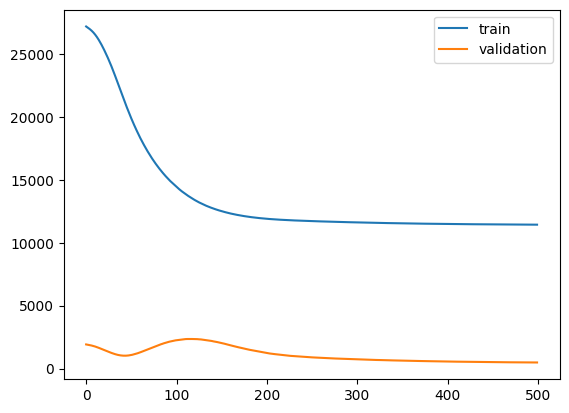

In [8]:
#adam ptimization
model.compile(optimizer="adam", loss="mean_squared_error", metrics=['mae'])

#fit the model
history = model.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=500)

#training and validation performance
# evaluate the model
_, train_acc = model.evaluate(X_train_scaled, df_train_y, verbose=0)
_, test_acc = model.evaluate(X_test_scaled, df_test_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

import matplotlib.pyplot as plt
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

In [ ]:
# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Model Description Below

***The validation curve appears to dip lowest near the 300 mark while the training loss plateaus around 120. Past this point a pataeu s observed in both training and validation. Validation is always consistently lower than training, indicating that it is most likely good at generalization. This show no over or underfitting to the data.***



---



## b) Deeper Network [1 point]

Construct and evaluate a model with 2 dense layers having a smaller number of neurons (e.g. 16, 8).

Epoch 1/750


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 27305.8613 - mae: 111.0963 - val_loss: 1954.1713 - val_mae: 35.9023
Epoch 2/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26341.6230 - mae: 108.0377 - val_loss: 1923.7646 - val_mae: 35.4843
Epoch 3/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25386.4023 - mae: 104.7879 - val_loss: 1887.9425 - val_mae: 34.9857
Epoch 4/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26399.4395 - mae: 109.7284 - val_loss: 1845.1627 - val_mae: 34.3848
Epoch 5/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 27265.1445 - mae: 110.8630 - val_loss: 1795.1173 - val_mae: 33.6651
Epoch 6/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27468.9688 - mae: 109.9017 - val_loss: 1737.6416 - val_mae: 32.8316
Epoch 7/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27402.7930 - mae: 109.3700 - val_loss: 1672.8444 - val_mae: 31.8795
Epoch 8/750
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26160.9648 - mae: 105.2179 - val_loss: 1600.8444 - val_mae: 30.

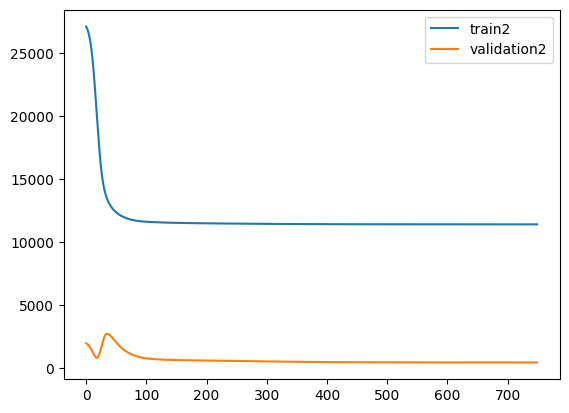

In [10]:
# your code here, use as many cells as you need

#sequential model
model2 = Sequential()

#first layer with 16 neurons
model2.add(Dense(units=16, activation='relu', input_shape=(n_features,)))

#second layer with 8 neurons
model2.add(Dense(units=8, activation='relu'))

#output layer
model2.add(Dense(units=1))

#adam ptimization
model2.compile(optimizer="adam", loss="mean_squared_error", metrics=['mae'])

#fit the model
history2 = model2.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=750)

#training and validation performance
_, train_acc = model2.evaluate(X_train_scaled, df_train_y, verbose=0)
_, test_acc = model2.evaluate(X_test_scaled, df_test_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

import matplotlib.pyplot as plt2
# plot training history
plt2.plot(history2.history['loss'], label='train2')
plt2.plot(history2.history['val_loss'], label='validation2')
plt2.legend()
plt2.show()

# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content


In [9]:
#Model Description below

***The validation curve appears to dip lowest near the 150 mark while the training loss curve plateaus around 90-100. Past this point a pataeu is observed in both training and validation. Validation is always consistently lower than training, indicating that it is most likely good at generalization. This show no over or underfitting to the data. With the increase in layers and lower neurons it still takes a bit of data before it stabilizes.***



---



## c) Wider Network [1 point]

Construct and evaluate a wider model with more neurons (e.g. 32, 16).

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 26510.7441 - mae: 109.4242 - val_loss: 1998.9758 - val_mae: 36.5972
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27157.4941 - mae: 110.7885 - val_loss: 1956.3727 - val_mae: 36.0240
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 29140.5703 - mae: 115.5018 - val_loss: 1912.8190 - val_mae: 35.4230
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27342.9785 - mae: 111.6991 - val_loss: 1866.0521 - val_mae: 34.7587
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27260.9746 - mae: 110.0513 - val_loss: 1813.7640 - val_mae: 33.9942
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27879.9102 - mae: 111.3398 - val_loss: 1752.2266 - val_mae: 33.0811
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25875.9023 - mae: 106.3783 - val_loss: 1679.9681 - val_mae: 32.0149
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25133.3691 - mae: 104.4634 - val_loss: 1596.4791 - val_mae: 30.

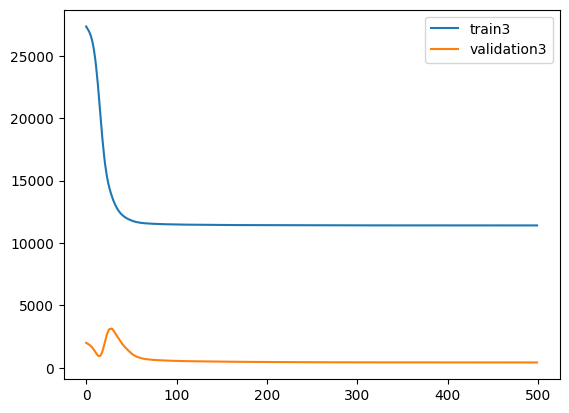

In [11]:
# your code here, use as many cells as you need

#sequential model
model3 = Sequential()

#first layer with 32 neurons
model3.add(Dense(units=32, activation='relu', input_shape=(n_features,)))

#second layer with 16 neurons
model3.add(Dense(units=16, activation='relu'))

#output layer
model3.add(Dense(units=1))

#adam ptimization
model3.compile(optimizer="adam", loss="mean_squared_error", metrics=['mae'])

#fit the model
history3 = model3.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=500)

#training and validation performance
_, train_acc = model3.evaluate(X_train_scaled, df_train_y, verbose=0)
_, test_acc = model3.evaluate(X_test_scaled, df_test_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

import matplotlib.pyplot as plt3
# plot training history
plt3.plot(history3.history['loss'], label='train3')
plt3.plot(history3.history['val_loss'], label='validation3')
plt3.legend()
plt3.show()

# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Answer below

***The validation curve appears to dip lowest near the 75-90 mark. Past this point a pataeu is observed in both training and validation. Validation is always consistently lower than training, indicating that it is most likely good at generalization. This show no over or underfitting to the data. With the increase in layers and higher neurons, compared to the previous mode it takes less time before it stabilizes.***



---



# Part 2: Hyperparameter Tuning Experiments

In the following experiments, you will evaluate and compare models trained with different hyperparameters. Please follow the specifications given for each model.

## a) Model 1 [2 points]

- 2 Dense layers:
  - The first with 64 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 28746.7168 - mae: 114.4194 - val_loss: 1933.1510 - val_mae: 35.6705
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25297.1230 - mae: 106.1582 - val_loss: 1835.1239 - val_mae: 34.2942
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27781.3008 - mae: 111.8190 - val_loss: 1703.7681 - val_mae: 32.3906
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25755.8945 - mae: 105.6267 - val_loss: 1531.0870 - val_mae: 29.7414
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25283.5137 - mae: 102.2513 - val_loss: 1317.1267 - val_mae: 26.4119
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26437.1094 - mae: 103.5155 - val_loss: 1088.9966 - val_mae: 23.1238
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21495.3105 - mae: 92.0493 - val_loss: 906.8497 - val_mae: 21.4078
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21006.7285 - mae: 94.0902 - val_loss: 874.3873 - val_mae: 22.5187

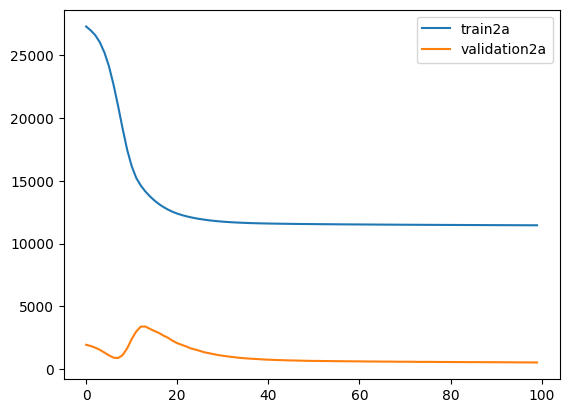

In [12]:
# your code here, use as many cells as you need

#sequential model
model2a = Sequential()

#first layer with 64 neurons
model2a.add(Dense(units=64, activation='relu', input_shape=(n_features,)))

#second layer with 64 neurons
model2a.add(Dense(units=64, activation='relu'))

#output layer
model2a.add(Dense(units=1, activation='linear'))

#adam ptimization
model2a.compile(optimizer="adam", loss="mse", metrics=['mae'])

#fit the model
history2a = model2a.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=100)

#training and validation performance
mae_scores2a = []
model2a_mae = model2a.evaluate(X_test_scaled, df_test_y, verbose=0)[1]
mae_scores2a.append(model2a_mae)
import numpy as np
mae_scores2a_array = np.array(mae_scores2a)

#MAE from CV with standard deviation.
print(f"Cross-validated MAE Scores: {mae_scores2a_array.mean():.2f} ± {mae_scores2a_array.std():.2f}")

import matplotlib.pyplot as plt2a
# plot training history
plt2a.plot(history2a.history['loss'], label='train2a')
plt2a.plot(history2a.history['val_loss'], label='validation2a')
plt2a.legend()
plt2a.show()


# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Model Description Below

***For this model, trained for 100 epochs, it can be seen that the validation loss for model 2a spikes around 12-15 and then slowly tapers until it stabilizes low around 30. The training loss for 2a shows a sharp drop with a plateau around 20. This could be beacuse relu activation is a good for fast training on complex datasets. With a MAE score of 19.38 this model could be seen as less than optimal as there are higher averages of error between training and validation.***



---



## b) Model 2 [2 points]

- 2 Dense layers:
  - The first with 128 neurons using a ReLU activation function.
  - The second with 64 neurons using a ReLU activation function.
- Choose an appropriate output layer and activation.
- Train model with 100 epochs and obtain cross-validated performance (e.g. with 3 cross-folds).
- Plot both loss and mean absolute error (i.e. learning curves) for both training and validation.
- Report MAE from CV with standard deviation.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 27123.0527 - mae: 110.9256 - val_loss: 1911.9923 - val_mae: 35.3586
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26956.8555 - mae: 109.8586 - val_loss: 1772.3373 - val_mae: 33.3649
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27260.3477 - mae: 109.2260 - val_loss: 1577.7209 - val_mae: 30.6089
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24812.7246 - mae: 102.7448 - val_loss: 1316.3448 - val_mae: 26.9613
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 23587.2324 - mae: 98.1589 - val_loss: 1029.6549 - val_mae: 23.2293
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22330.0254 - mae: 94.8971 - val_loss: 854.7206 - val_mae: 21.4791
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20539.9434 - mae: 93.1324 - val_loss: 1058.5062 - val_mae: 25.4419
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18995.7715 - mae: 97.2190 - val_loss: 1839.2415 - val_mae: 35.1566


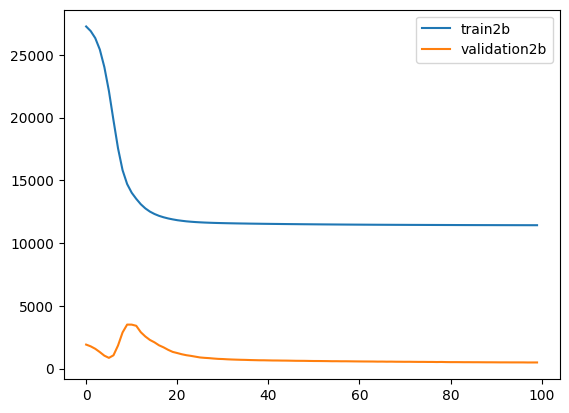

In [13]:
# your code here, use as many cells as you need

#sequential model
model2b = Sequential()

#first layer with 128 neurons
model2b.add(Dense(units=128, activation='relu', input_shape=(n_features,)))

#second layer with 64 neurons
model2b.add(Dense(units=64, activation='relu'))

#output layer
model2b.add(Dense(units=1, activation='linear'))

#adam ptimization
model2b.compile(optimizer="adam", loss="mse", metrics=['mae'])

#fit the model
history2b = model2b.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=100)

#training and validation performance
mae_scores2b = []
model2b_mae = model2b.evaluate(X_test_scaled, df_test_y, verbose=0)[1]
mae_scores2b.append(model2b_mae)
import numpy as np
mae_scores2b_array = np.array(mae_scores2b)

#MAE from CV with standard deviation.
print(f"Cross-validated MAE Scores: {mae_scores2b_array.mean():.2f} ± {mae_scores2b_array.std():.2f}")

import matplotlib.pyplot as plt2b
# plot training history
plt2b.plot(history2b.history['loss'], label='train2b')
plt2b.plot(history2b.history['val_loss'], label='validation2b')
plt2b.legend()
plt2b.show()

# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Model Description Below

***In comparison to model 2a, 2b has double the amount of neurons in the first layer. There is a visible spike in validation loss around 10 and a steady taper until stability at around 26-28. For the training loss, there is a steep drop until a plateau around 18-20. Similar to the initial base test in 2a, this model converges fast and then stays as at that level without more learning or improvement. This intense drop in learning could be because some neurons go unused or not used often with such a large first hidden layer. The MAE score of this model, 18.45, compared to 2a, with fewer neurons in the first layer, indicates that the more neurons in the layer, the quicker it will learn, producing slightly less averaged errors.***



---



## c) Model 3 [2 points]

- Same as Model 2, but use tanh activation functions instead of relu.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 27163.1406 - mae: 111.9506 - val_loss: 2108.7703 - val_mae: 38.0403
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27755.4688 - mae: 113.2050 - val_loss: 2184.2922 - val_mae: 39.1781
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28229.4922 - mae: 113.4652 - val_loss: 2262.4324 - val_mae: 40.3720
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26994.3965 - mae: 110.7546 - val_loss: 2368.9592 - val_mae: 41.8179
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27451.9941 - mae: 112.0791 - val_loss: 2455.3418 - val_mae: 43.0175
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26798.6055 - mae: 110.3275 - val_loss: 2461.0298 - val_mae: 43.3132
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25272.6465 - mae: 105.8468 - val_loss: 2360.7947 - val_mae: 42.3737
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25603.8301 - mae: 106.5660 - val_loss: 2128.2305 - val_mae: 39

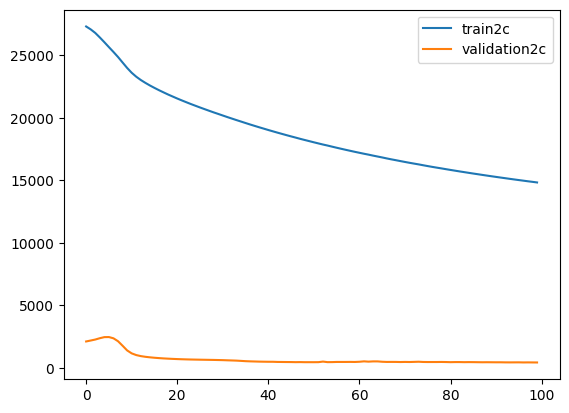

In [14]:
# your code here, use as many cells as you need

#sequential model
model2c = Sequential()

#first layer with 128 neurons
model2c.add(Dense(units=128, activation='tanh', input_shape=(n_features,)))

#second layer with 64 neurons
model2c.add(Dense(units=64, activation='tanh'))

#output layer
model2c.add(Dense(units=1, activation='linear'))

#adam ptimization
model2c.compile(optimizer="adam", loss="mse", metrics=['mae'])

#fit the model
history2c = model2c.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=100)

#training and validation performance
mae_scores2c = []
model2c_mae = model2c.evaluate(X_test_scaled, df_test_y, verbose=0)[1]
mae_scores2c.append(model2c_mae)
import numpy as np
mae_scores2c_array = np.array(mae_scores2c)

#MAE from CV with standard deviation.
print(f"Cross-validated MAE Scores: {mae_scores2c_array.mean():.2f} ± {mae_scores2c_array.std():.2f}")

import matplotlib.pyplot as plt2c
# plot training history
plt2c.plot(history2c.history['loss'], label='train2c')
plt2c.plot(history2c.history['val_loss'], label='validation2c')
plt2c.legend()
plt2c.show()

# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Model Decription Below

***Based on the plot produced for the tahn activation, adam optimized, model 2c drops more steadily compared to the other models for the training loss. There is no indication of an intense spike in the validation loss either, unlike the other models. This points towards the model being good at generalization. This could be due to the fact that tanh activation outputs are zero-centered which can lead to faster convergence and better training. The MAE scores tracked over the model 2c run, 16.92, shows that this model has the lowest score meaning it has the lowest average of errors between the training and test data***



---



## d) Model 4 [2 points]

- Same as Model 2, but use the rmsprop optimizer when training.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 27203.1582 - mae: 111.6186 - val_loss: 1831.6317 - val_mae: 34.2326
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26964.2500 - mae: 108.6853 - val_loss: 1630.4027 - val_mae: 31.3427
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25401.4395 - mae: 103.9841 - val_loss: 1400.6807 - val_mae: 28.0983
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24461.3516 - mae: 101.5611 - val_loss: 1165.6156 - val_mae: 24.6560
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21890.1133 - mae: 92.8769 - val_loss: 950.6252 - val_mae: 21.9644
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 21037.6875 - mae: 92.9754 - val_loss: 835.5615 - val_mae: 21.3104
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19934.1230 - mae: 92.7864 - val_loss: 870.7919 - val_mae: 22.7833
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17773.3379 - mae: 91.2733 - val_loss: 1115.0618 - val_mae: 26.5796
E

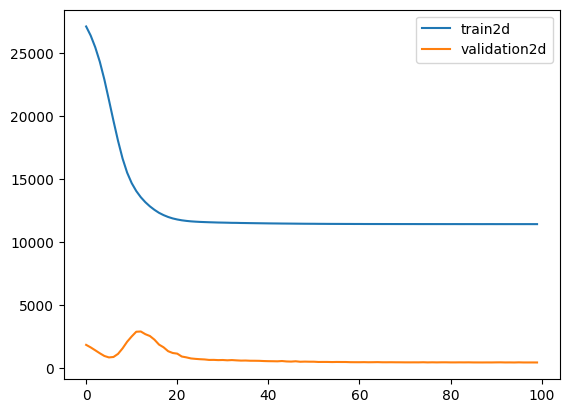

In [15]:
# your code here, use as many cells as you need

#sequential model
model2d = Sequential()

#first layer with 128 neurons
model2d.add(Dense(units=128, activation='relu', input_shape=(n_features,)))

#second layer with 64 neurons
model2d.add(Dense(units=64, activation='relu'))

#output layer
model2d.add(Dense(units=1, activation='linear'))

#adam ptimization
model2d.compile(optimizer="RMSprop", loss="mse", metrics=['mae'])

#fit the model
history2d = model2d.fit(X_train_scaled, df_train_y, validation_data=(X_test_scaled, df_test_y), epochs=100)

#training and validation performance
mae_scores2d = []
model2d_mae = model2d.evaluate(X_test_scaled, df_test_y, verbose=0)[1]
mae_scores2d.append(model2d_mae)
import numpy as np
mae_scores2d_array = np.array(mae_scores2d)

#MAE from CV with standard deviation.
print(f"Cross-validated MAE Scores: {mae_scores2d_array.mean():.2f} ± {mae_scores2d_array.std():.2f}")

import matplotlib.pyplot as plt2d
# plot training history
plt2d.plot(history2d.history['loss'], label='train2d')
plt2d.plot(history2d.history['val_loss'], label='validation2d')
plt2d.legend()
plt2d.show()

# be sure to comment on your results for each and every question, describing not just
# the what, but the 'how' and 'why' where possible, to demonstrate your understanding of
# course content

In [ ]:
#Model Description Below

***Model 2d shows a spike in validation loss around 12-14 with a taper off until it stabilizes around 22-23. The training loss appears to drop significantly until it plateaus around 22-23 as well. This, similar to 2a and 2b, indicates that there is quick convergence and then no further improvement. With a MAE score of 17.11 this is the second best performing model for part 2, indicating that a change between adam and rmsprop optimizers makes a slight improvement on performance compared to 2b.***



---



## e) Model Comparison [1 point]

Which model performed best? Offer your thoughts on why the particular choice of hyperparameters led to improved performance for this model.

In [ ]:
# explain WHY you think the best model was better than the rest, in terms
# of how those hyperparameters theoretically impact the model

Based on the hyper paramaters that were adjusted with each model, it can be observed that the a, b, and d models performed in similar manners, however based on MAE scores, a directed
correlation with accuracy, model c had the smallest MAE score average and standard deviation with a score of 17.00 making it the best performing.
Although the plot for the tanh model (c) does not have any spikes, this is an indication of stable training of the model. Likewise, training loss drops steadily and validation continually
stays low showing that patterns are being learned correctly and not biased.

# provide visualizations (e.g. tables or comparison plot) to support your response where possible

NOTE: 2 additional points are awarded based on code documentation and overall clarity of work.

In [ ]:
# We are looking for a clear explanation of results with each response. We want you to attempt to
# explain the _how_ and _why_ behind your answers, and not just the what, do demonstrate
# your knowledge of the concepts discussed in class. Answers should be backed up with
# visualizations (e.g. plots, charts).

# Code should be easy to follow by using sensical naming conventions for function and variable
# names, providing useful code comments, and refactoring repeated code into re-usable functions.